In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('ToyotaCorolla.csv', encoding='latin1')
print('Размер датасета: ', df.shape)
df.head()

Размер датасета:  (1436, 39)


,ï»¿Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0



информация о данных
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ï»¿Id              1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      14

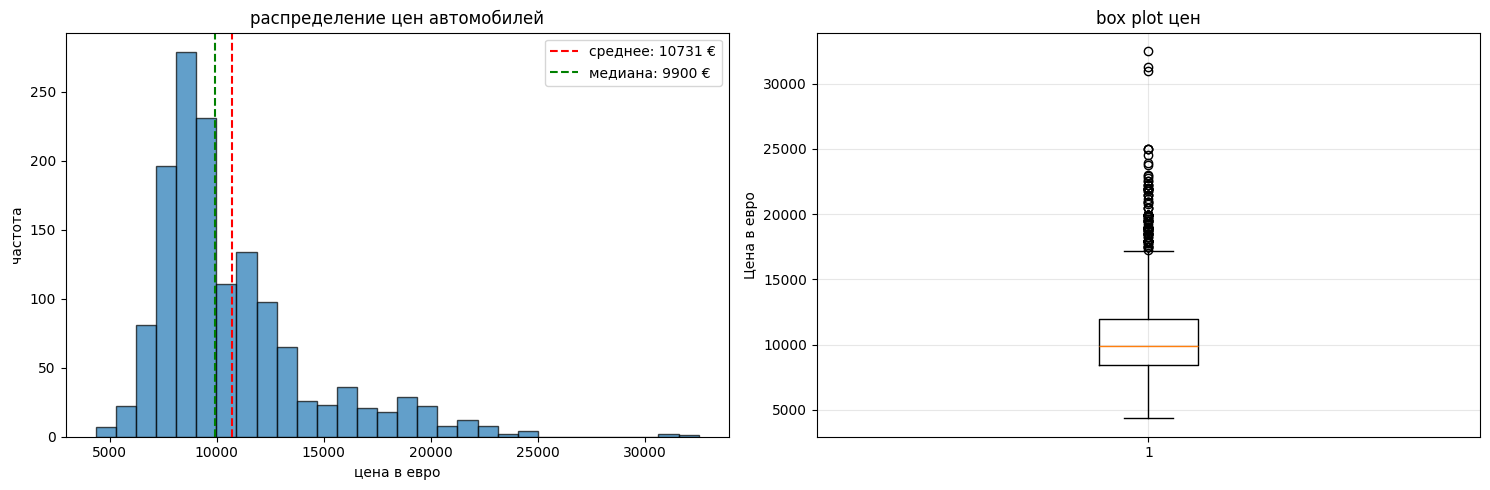


корелляционный анализ
корреляция признаков с ценой:
Price                1.000000
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Parking_Assistant    0.044375
Automatic            0.033081
BOVAG_Guarantee      0.028133
Mfg_Month           -0.018138
Radio               -0.041887
Radio_cassette      -0.043179
Tow_Bar          

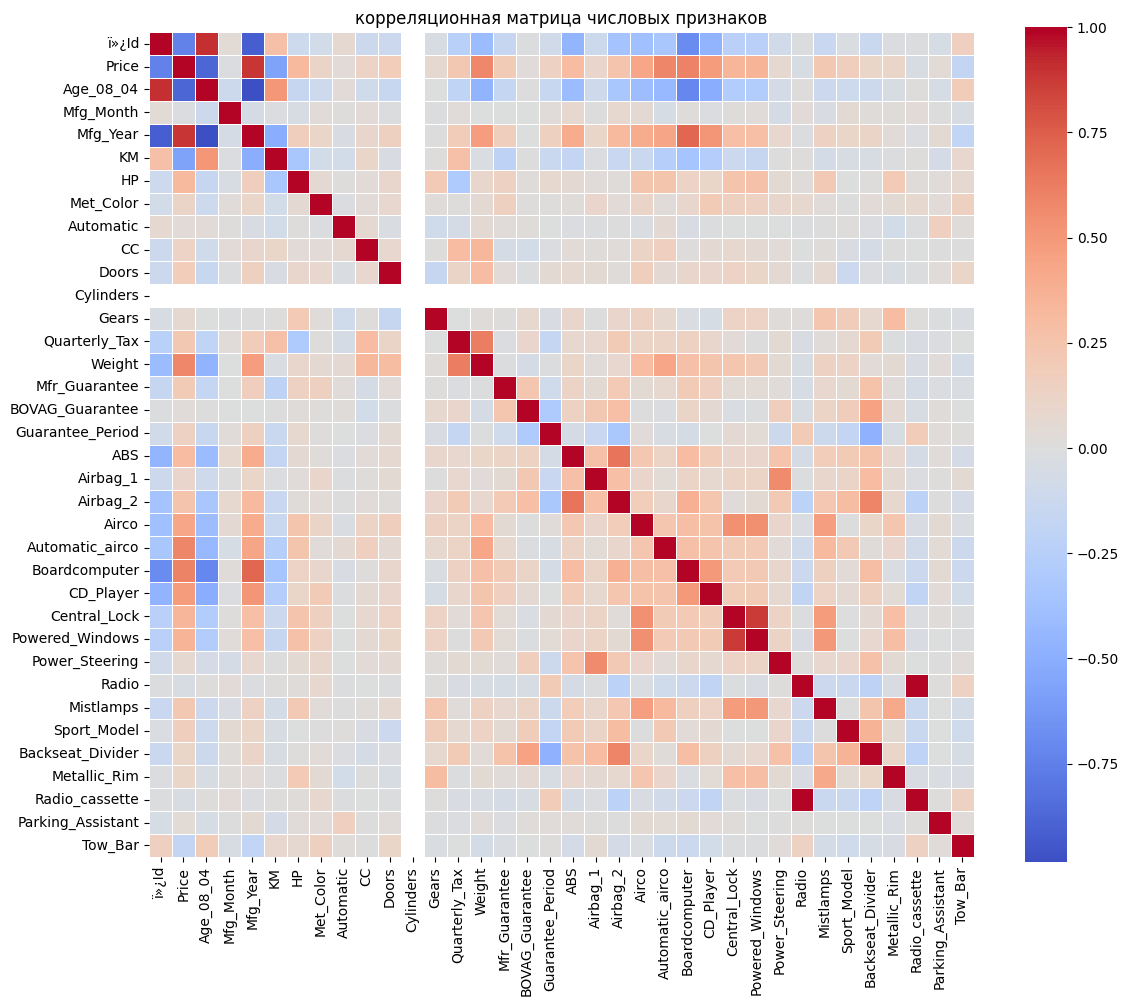

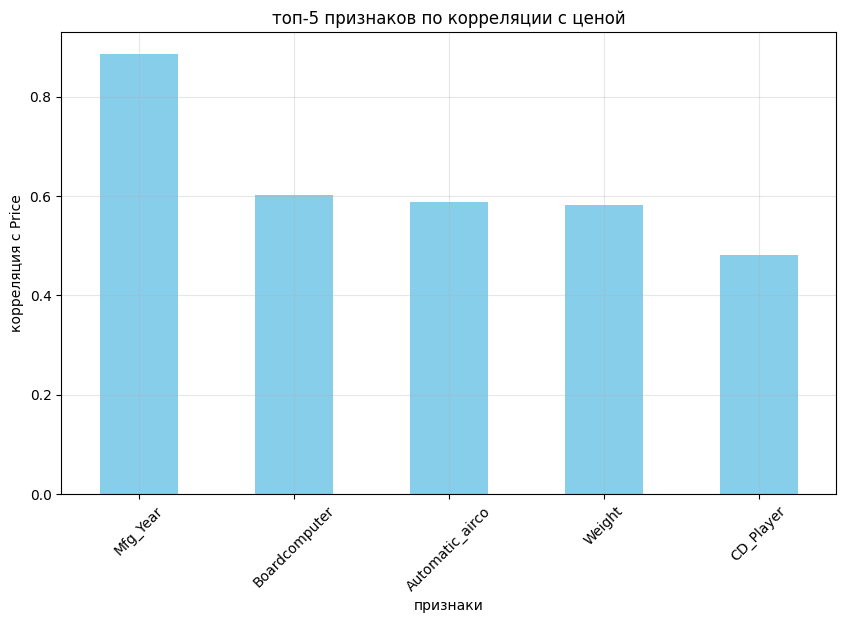

In [4]:
print("\nинформация о данных")
print(df.info())

print("\n проверка пропусков")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропусков': missing_data,
    'Процент': missing_percent
})
print(missing_df[missing_df['Пропусков'] > 0])

print(df.describe())

print("\nанализ целевой переменной")
print(f"Средняя цена: {df['Price'].mean():.2f} €")
print(f"Медианная цена: {df['Price'].median():.2f} €")
print(f"Минимальная цена: {df['Price'].min():.2f} €")
print(f"Максимальная цена: {df['Price'].max():.2f} €")
print(f"Стандартное отклонение: {df['Price'].std():.2f} €")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['Price'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('цена в евро')
axes[0].set_ylabel('частота')
axes[0].set_title('распределение цен автомобилей')
axes[0].axvline(df['Price'].mean(), color='red', linestyle='--', label=f'среднее: {df["Price"].mean():.0f} €')
axes[0].axvline(df['Price'].median(), color='green', linestyle='--', label=f'медиана: {df["Price"].median():.0f} €')
axes[0].legend()

axes[1].boxplot(df['Price'])
axes[1].set_ylabel('Цена в евро')
axes[1].set_title('box plot цен')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nкорелляционный анализ")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

price_corr = corr_matrix['Price'].sort_values(ascending=False)
print("корреляция признаков с ценой:")
print(price_corr)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

top_features = price_corr[1:6]
plt.figure(figsize=(10, 6))
top_features.plot(kind='bar', color='skyblue')
plt.title('топ-5 признаков по корреляции с ценой')
plt.xlabel('признаки')
plt.ylabel('корреляция с Price')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
df_processed = df.copy()

# удаление неинформативных признаков
if 'Id' in df_processed.columns:
    df_processed.drop('Id', axis=1, inplace=True)

# создание нового признака «возраст автомобиля»
if 'Mfg_Year' in df_processed.columns:
    current_year = 2026
    df_processed['Car_Age'] = current_year - df_processed['Mfg_Year']

# признак «интенсивность использования» (пробег / возраст)
if 'KM' in df_processed.columns and 'Car_Age' in df_processed.columns:
    df_processed['KM_per_Year'] = df_processed['KM'] / (df_processed['Car_Age'] + 1)

y = df_processed['Price']
X = df_processed.drop('Price', axis=1)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Числовых признаков: {len(numeric_features)}")
print(f"Категориальных признаков: {len(categorical_features)}: {categorical_features}")

Числовых признаков: 37
Категориальных признаков: 3: ['Model', 'Fuel_Type', 'Color']


In [6]:
# разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"размер обучающей выборки (X_train): {X_train.shape}")
print(f"размер тестовой выборки  (X_test):  {X_test.shape}")
print(f"соотношение: {len(X_train)/len(X)*100:.1f}% / {len(X_test)/len(X)*100:.1f}%")
print(f"средняя цена в обучающей выборке: {y_train.mean():.2f} €")
print(f"средняя цена в тестовой выборке:  {y_test.mean():.2f} €")

размер обучающей выборки (X_train): (1148, 40)
размер тестовой выборки  (X_test):  (288, 40)
соотношение: 79.9% / 20.1%
средняя цена в обучающей выборке: 10754.40 €
средняя цена в тестовой выборке:  10636.87 €


Для линейной регрессии необходима предобработка, так как линейная модель чувствительна к масштабу признаков

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

start_time = time.time()
lr_pipeline.fit(X_train, y_train)
lr_time = time.time() - start_time

y_pred_lr = lr_pipeline.predict(X_test)

lr_r2   = r2_score(y_test, y_pred_lr)
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f" Линейная регрессия ")
print(f"Время обучения : {lr_time:.4f} сек")
print(f"R²             : {lr_r2:.4f}")
print(f"MAE            : {lr_mae:.2f} €")
print(f"RMSE           : {lr_rmse:.2f} €")

 Линейная регрессия 
Время обучения : 0.0901 сек
R²             : 0.5218
MAE            : 1221.17 €
RMSE           : 2526.03 €


## Случайный лес

### Предобработка данных для случайного леса
Случайный лес —  модель типа дерева, поэтому:
- StandartScaler не нужен, так как дерево не чувствительно к масштабу.
- OneHotEncoder нужен: sklearn не умеет работать со строковыми категориальными признаками напрямую.

Таким образом, предобработка отличается от линейной модели: числовые признаки передаются без масштабирования.

### Разделение выборки
Использовано разделение 80% / 20% (train/test) — такое же, как для линейной регрессии.

### Кросс-валидация
При использовании кросс-валидации выборку не нужно делить вручную на train/val,  CV делает это автоматически внутри train-части. Стандартное количество фолдов — 5 (cv=5): даёт хороший баланс между надёжностью оценки и временем вычисления. При маленьких датасетах используют 10.

### Можно ли обойтись без кросс-валидации?
Да. Тогда выборку делят на 3 части: train / validation / test. Train — обучение, validation — подбор гиперпараметров, test — финальная оценка. Недостаток: оценка менее стабильна и зависит от конкретного разбиения.

In [8]:
# предобработка для случайного дерева: числовые признаки — без масштабирования
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

RF_MAX_DEPTH = 15  # глубина, которую используем и для RF, и для одного дерева

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=RF_MAX_DEPTH,
        random_state=42,
        n_jobs=-1
    ))
])

start_time = time.time()
rf_pipeline.fit(X_train, y_train)
rf_time = time.time() - start_time

y_pred_rf = rf_pipeline.predict(X_test)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# 5-fold кросс-валидация по R² на обучающей выборке
cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='r2')

print(f"=== Случайный лес (100 деревьев, max_depth={RF_MAX_DEPTH}) ===")
print(f"Время обучения : {rf_time:.4f} сек")
print(f"R²  (тест)     : {rf_r2:.4f}")
print(f"MAE (тест)     : {rf_mae:.2f} €")
print(f"RMSE (тест)    : {rf_rmse:.2f} €")
print(f"CV R² (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

=== Случайный лес (100 деревьев, max_depth=15) ===
Время обучения : 1.4622 сек
R²  (тест)     : 0.9306
MAE (тест)     : 740.02 €
RMSE (тест)    : 961.94 €
CV R² (5-fold) : 0.9076 ± 0.0154


## Одно дерево той же глубины (max_depth=15)

In [9]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('regressor', DecisionTreeRegressor(
        max_depth=RF_MAX_DEPTH,
        random_state=42
    ))
])

start_time = time.time()
dt_pipeline.fit(X_train, y_train)
dt_time = time.time() - start_time

y_pred_dt = dt_pipeline.predict(X_test)

dt_r2   = r2_score(y_test, y_pred_dt)
dt_mae  = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"=== Одно дерево решений (max_depth={RF_MAX_DEPTH}) ===")
print(f"Время обучения : {dt_time:.4f} сек")
print(f"R²  (тест)     : {dt_r2:.4f}")
print(f"MAE (тест)     : {dt_mae:.2f} €")
print(f"RMSE (тест)    : {dt_rmse:.2f} €")

=== Одно дерево решений (max_depth=15) ===
Время обучения : 0.0389 сек
R²  (тест)     : 0.8612
MAE (тест)     : 1013.59 €
RMSE (тест)    : 1360.93 €


## Итоговое сравнение всех моделей

                 Модель       R²      MAE, €     RMSE, €  Время, сек
       LinearRegression 0.521776 1221.172863 2526.033180    0.090091
DecisionTree (depth=15) 0.861188 1013.589334 1360.931359    0.038893
RandomForest (depth=15) 0.930649  740.018973  961.943144    1.462205


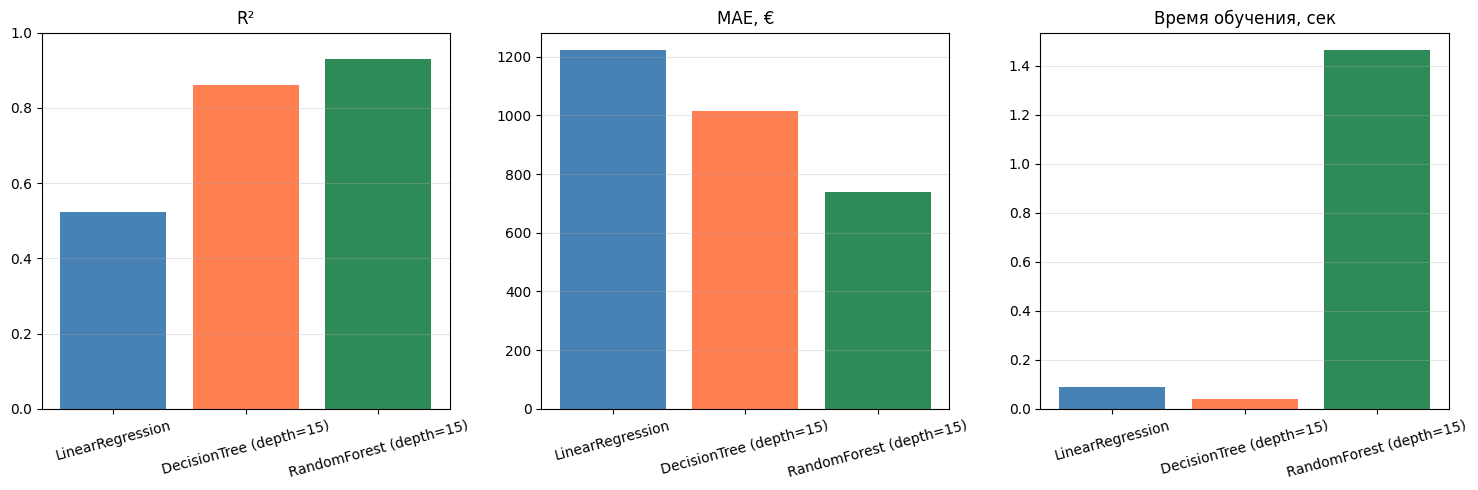


 Лучшая модель: RandomForest (depth=15)
R² на тесте: 0.9306
MAE на тесте: 740.02 €


In [11]:
results = pd.DataFrame({
    'Модель': ['LinearRegression', f'DecisionTree (depth={RF_MAX_DEPTH})', f'RandomForest (depth={RF_MAX_DEPTH})'],
    'R²':     [lr_r2,  dt_r2,  rf_r2],
    'MAE, €': [lr_mae, dt_mae, rf_mae],
    'RMSE, €':[lr_rmse,dt_rmse,rf_rmse],
    'Время, сек': [lr_time, dt_time, rf_time]
})

print(results.to_string(index=False))

# визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = results['Модель']
colors = ['steelblue', 'coral', 'seagreen']

axes[0].bar(models, results['R²'], color=colors)
axes[0].set_title('R²')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models, results['MAE, €'], color=colors)
axes[1].set_title('MAE, €')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(models, results['Время, сек'], color=colors)
axes[2].set_title('Время обучения, сек')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

best = results.loc[results['R²'].idxmax()]
print(f"\n Лучшая модель: {best['Модель']}")
print(f"R² на тесте: {best['R²']:.4f}")
print(f"MAE на тесте: {best['MAE, €']:.2f} €")

Сравнение скорости: Одно дерево обучается значительно быстрее случайного леса, так как лес строит 100 деревьев. Линейная регрессия — самая быстрая из всех.
Можно ли уравнять скорость? Частично можно, уменьшив количество деревьев, но тогда будем терять в эффективности, можно также использовать n_jobs = -1 для задействования всех ядер
Сравнение качества: у линейной регрессии r2 = 0,53; у одного дерева 0,86; а у случайного леса 0,93; другие метрики также показывают ожидаемую победу случайного леса
Метрики: использованы R², MAE и RMSE. MAE показывает среднюю ошибку в евро. RMSE штрафует сильнее за крупные ошибки, что важно при оценке автомобилей (большой промах дороже обходится). R² показывает, какую долю дисперсии цены объясняет модель — удобно для сравнения моделей между собой. Таким образом для анализа были выбраны самые базовые метрики для задачи регрессии, так как они лучшим образом показывают результат.
Метрики считались на test части, которую модели не видели в процессе обучения.
Лучшей моделью оказался случайный лес.
Для решающего дерева и случайного леса метрики и реультаты оказались довольно хорошими, для линейной регрессии результаты намного хуже(
